# Overfitting vs. Underfitting — Seeing It With SVM

Every model lives on a spectrum between **too simple** and **too complex**:

- **Underfitting** — the model is too simple to capture the real pattern. It does poorly on *both* the training data and new data.
- **Good fit** — the model captures the real pattern without memorizing noise. It does well on both.
- **Overfitting** — the model is so complex it memorizes the training data (including its noise). It looks great on training data but fails on new data.

The tell-tale sign of overfitting is a **big gap**: high training score, low test score.

We'll make this visible with an SVM. Its `rbf` kernel has a **`gamma`** dial that controls complexity — small `gamma` = a smooth, simple boundary; large `gamma` = a wildly wiggly one. By turning that one dial we can walk from underfitting straight through to overfitting.

> We use a small **2-D synthetic dataset** here for one reason: with only two features we can actually *draw* the decision boundary and see what each model is doing.

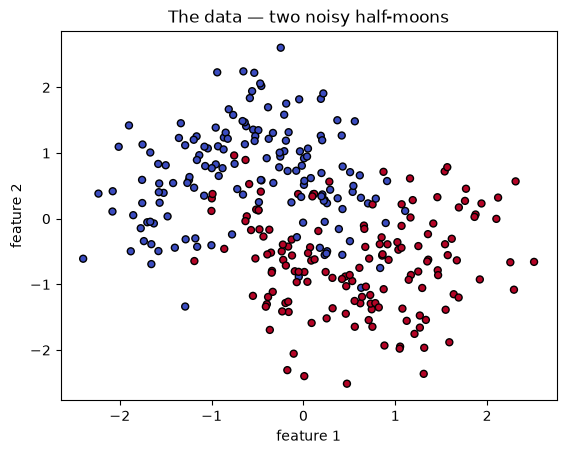

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Two interleaving half-moons with some noise — needs a curved boundary
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
plt.title('The data — two noisy half-moons')
plt.xlabel('feature 1'); plt.ylabel('feature 2')
plt.show()

The two classes clearly need a **curved** boundary to separate them, and the noise means they overlap a bit — so no model will (or should) get 100% right. That overlap is exactly what an overfit model will try to memorize.

## Demo 1 — Watch the boundary change

Let's train the same SVM at three `gamma` values and **draw the boundary** each one learns. The helper below shades the region each model would classify as class 0 vs class 1.

In [2]:
def plot_boundary(ax, clf, title):
    """Shade the decision regions of a fitted classifier, with the data on top."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
               cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

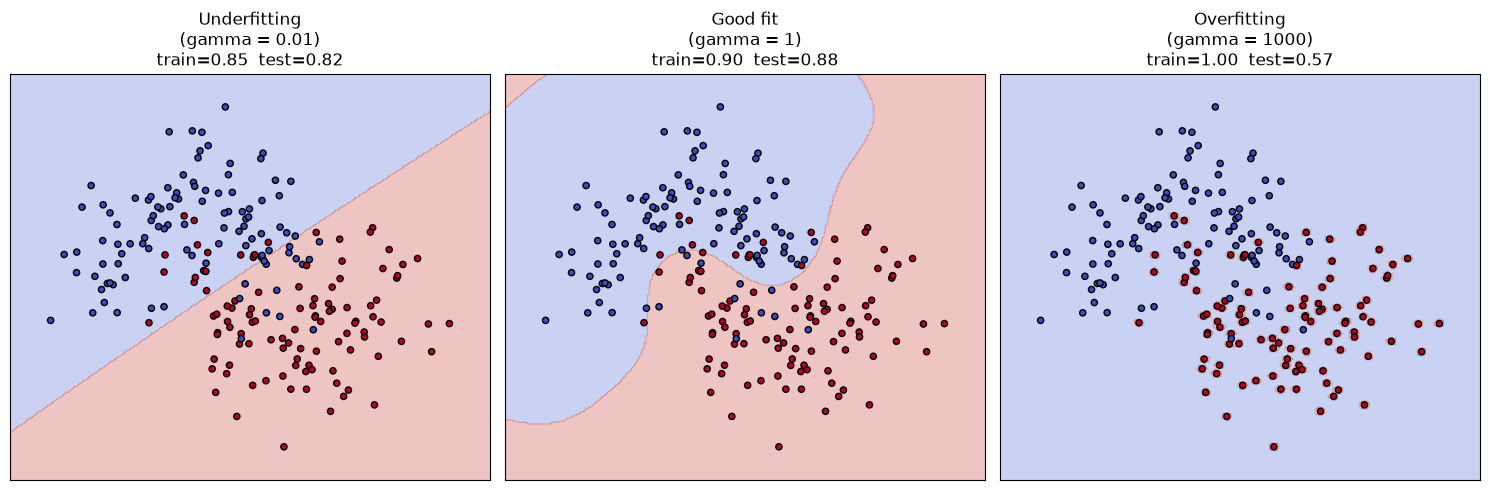

In [3]:
settings = [
    (0.01, 'Underfitting\n(gamma = 0.01)'),
    (1,    'Good fit\n(gamma = 1)'),
    (1000, 'Overfitting\n(gamma = 1000)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (gamma, title) in zip(axes, settings):
    clf = SVC(kernel='rbf', gamma=gamma, C=1).fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    plot_boundary(ax, clf, f'{title}\ntrain={train_acc:.2f}  test={test_acc:.2f}')
plt.tight_layout()
plt.show()

Read the three panels left to right:

- **Left (underfitting, `gamma=0.01`)** — the boundary is almost a straight line. It's too simple to follow the moon shapes, so it misclassifies points even on the *training* set. Train and test scores are both mediocre **and close together**.
- **Middle (good fit, `gamma=1`)** — a smooth curve that follows the real moon pattern without chasing individual points. Train and test scores are both high and close.
- **Right (overfitting, `gamma=1000`)** — the boundary breaks into little **islands** wrapped around individual training points, memorizing the noise. Training score is nearly perfect, but the test score falls off a cliff — the model learned the *training set*, not the *pattern*.

That collapsing test score on the right, next to a near-perfect train score, is the signature of overfitting.

## Demo 2 — Diagnose it with a validation curve

Eyeballing boundaries is nice, but in practice you have more than two features and can't plot them. The standard *diagnostic* is a **validation curve**: sweep the complexity dial across a wide range and plot the **training score** against the **cross-validated test score**.

- Where both curves are **low** → underfitting (too simple).
- Where they are **high and close** → the sweet spot.
- Where the training curve stays high but the test curve **drops away** → overfitting. The **gap between the curves** is how much the model is overfitting.

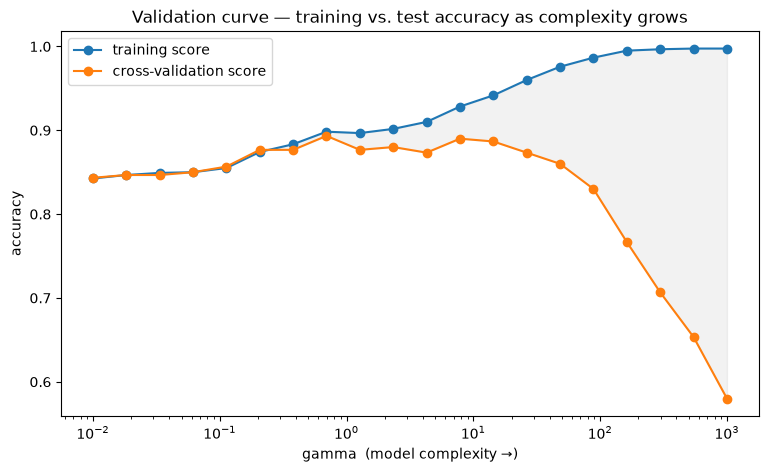

In [4]:
from sklearn.model_selection import validation_curve

gamma_range = np.logspace(-2, 3, 20)   # from 0.01 to 1000
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', C=1), X, y,
    param_name='gamma', param_range=gamma_range,
    cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(9, 5))
plt.semilogx(gamma_range, train_mean, 'o-', label='training score')
plt.semilogx(gamma_range, test_mean, 'o-', label='cross-validation score')
plt.fill_between(gamma_range, train_mean, test_mean, alpha=0.1, color='grey')
plt.xlabel('gamma  (model complexity \u2192)')
plt.ylabel('accuracy')
plt.title('Validation curve — training vs. test accuracy as complexity grows')
plt.legend()
plt.show()

Reading this one chart tells the whole story:

- **Far left (small gamma)** — both curves sit low: the model is too simple → **underfitting**.
- **Middle** — the cross-validation score peaks (around `gamma ≈ 1`). This is the **sweet spot** you'd actually pick.
- **Far right (large gamma)** — the training score climbs toward 1.0 while the cross-validation score **plunges**. The widening grey gap between them *is* the overfitting.

The best model isn't the one with the highest *training* score — it's the one at the **peak of the test curve**.

## What we learned

- **Underfitting** = too simple → poor on training *and* test data (scores low and close).
- **Overfitting** = too complex → memorizes training noise → great on training, poor on test (**big gap**).
- **Good fit** = highest *test* score, with training and test close together.
- For an SVM's `rbf` kernel, **`gamma`** (and to a lesser extent **`C`**) is the complexity dial that moves you along this spectrum.

**How to fight overfitting:**
- Reduce complexity — lower `gamma` / lower `C`, or use a simpler kernel.
- Get **more training data** — noise averages out, memorizing gets harder.
- Use **cross-validation** (like the validation curve above) to pick settings by *test* performance, not training performance.

**Try next:** redo the validation curve with `C` as the dial instead of `gamma`, or use `GridSearchCV` to find the sweet spot automatically.